# LLM-Powered Intelligent Job Matching System

**Name**: PAINDA MOHAMMAD FAYAZ
**Student ID**: 22511204
**Date**: 2026-06
**Topic**: Job Matching

---

## 1. Problem Background

Recruiting teams face two scaling problems:

| Pain Point | Description |
|---|---|
| Low efficiency | HR spends 5-10 minutes manually comparing each resume to job requirements |
| Subjective scoring | Different recruiters use different criteria, hard to quantify |
| Black-box rejections | Candidates rarely learn *why* they were a poor fit |
| Multi-dimensional tradeoffs | Skills, experience, education, location, salary all matter — and the weights differ per role |

## 2. Solution

This project combines **rule-based scoring** with a **Large Language Model (LLM)**:

1. **Data input** — load job and candidate databases (CSV), supporting interactive selection
2. **Quantitative analysis** — compute a composite score from skills overlap, experience match, education match, location match
3. **Results display** — sortable table + dual bar charts (total + per-dimension)
4. **Parameter interaction** — adjust dimension weights, filter by location/salary, control the number of recommendations
5. **LLM enhancement** — call Qwen to generate a natural-language explanation and advice for the top recommendation

> **Why this design?**
> Pure rules are **transparent but rigid**; pure LLM is **flexible but opaque and expensive**.
> Combined: rules provide an auditable quantitative base, LLM adds semantic understanding and human-readable advice.


## 3. Setup

Load dependencies, configure plotting, and initialize the Qwen API client.


In [1]:
# Standard library
import os
import warnings
warnings.filterwarnings("ignore")

# Data & ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Jupyter interactivity
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown, HTML

# LLM (Qwen / Alibaba Cloud DashScope — OpenAI-compatible API)
from dotenv import load_dotenv
from openai import OpenAI

# Load environment variables
load_dotenv()
LLM_API_KEY = os.getenv("DASHSCOPE_API_KEY")
LLM_BASE_URL = os.getenv("LLM_BASE_URL", "https://dashscope.aliyuncs.com/compatible-mode/v1")
LLM_MODEL = os.getenv("LLM_MODEL", "qwen-plus")

client = None
if LLM_API_KEY and not LLM_API_KEY.startswith("sk-your-"):
    client = OpenAI(api_key=LLM_API_KEY, base_url=LLM_BASE_URL)
    print(f"Qwen API ready: model={LLM_MODEL}")
else:
    print("No DASHSCOPE_API_KEY detected — LLM features will use mock responses.")
    print("Copy .env.example to .env and add your DashScope API key to enable real LLM calls.")


No DASHSCOPE_API_KEY detected — LLM features will use mock responses.
Copy .env.example to .env and add your DashScope API key to enable real LLM calls.


---

## Module 1: Data Input

Load the job database (`jobs.csv`) and candidate database (`candidates.csv`).
**~80 jobs + ~25 candidates**, covering:
- **Backend**: Python / Java / Go / Node.js / Ruby / C++
- **Frontend**: React / Vue / Full Stack
- **Mobile**: iOS / Android / Flutter / React Native
- **Data & AI**: Data Analysis / Data Science / ML / NLP / CV / Recommendation / LLM
- **QA & DevOps**: Test Automation / DevOps / SRE / Cloud
- **Product & Design**: PM / UI / UX / Visual
- **Other**: Security / Blockchain / Embedded / FPGA

Companies span big tech (Google, Microsoft, Meta), AI labs (OpenAI, Anthropic, Mistral), unicorns (Stripe, Databricks), midsize (GitHub, Cloudflare), and startups. Locations across major US tech hubs + remote.


In [2]:
# Load datasets
jobs_df = pd.read_csv("data/jobs.csv")
candidates_df = pd.read_csv("data/candidates.csv")

print(f"Loaded: {len(jobs_df)} jobs / {len(candidates_df)} candidates\n")
print("=== Jobs preview (top 10) ===")
display(jobs_df.head(10))
print("\n=== Candidates preview (top 10) ===")
display(candidates_df.head(10))

# Quick stats
print("\n=== Data distribution ===")
print(f"Jobs by location: {dict(jobs_df['location'].value_counts())}")
print(f"Jobs by education requirement: {dict(jobs_df['education'].value_counts())}")
print(f"Candidates by education: {dict(candidates_df['education'].value_counts())}")
print(f"Salary range: ${jobs_df['salary_min'].min():,} - ${jobs_df['salary_max'].max():,}")


Loaded: 1070 jobs / 153 candidates

=== Jobs preview (top 10) ===


,job_id,title,company,location,required_skills,min_experience,education,salary_min,salary_max,description
0,J0930,Build & Release Engineer,Qualcomm,"Washington, DC","Bazel,Make,CI/CD,Jenkins,Python,Linux,Containe...",5,Bachelor,147152,225964,"Build and maintain CI/CD pipelines, manage clo..."
1,J0787,Gameplay Programmer (Unity),Activision Blizzard,"Santa Monica, CA","C#,Unity,Game Design,Animation,Physics,Mobile,...",3,Bachelor,116331,199041,Build the systems behind immersive gameplay — ...
2,J0410,Data Engineer,Elastic,Remote,"Python,SQL,Spark,Airflow,AWS,Kafka,ETL,Data Mo...",5,Bachelor,162293,259731,"Build and maintain CI/CD pipelines, manage clo..."
3,J0846,Computational Biologist,GitHub,Remote,"Python,R,Bioinformatics,Statistics,Machine Lea...",3,PhD,167307,248464,Combine software engineering with biology to a...
4,J0864,Climate Tech Software Engineer,Adobe,"San Jose, CA","Python,GIS,Geospatial,PostgreSQL,AWS,Data Pipe...",3,Bachelor,158237,239367,Build software that addresses climate change —...
5,J0694,Robotics Software Engineer,Cruise,"San Francisco, CA","C++,Python,ROS,Computer Vision,SLAM,Linux,Cont...",4,Master,154059,265991,Develop firmware and embedded software for har...
6,J0999,Quantum Computing Engineer,Khan Academy,"Mountain View, CA","Python,Qiskit,Cirq,Linear Algebra,Physics,Math...",3,PhD,164987,282182,Design low-latency systems and quantitative st...
7,J0836,Bioinformatics Engineer,Roblox,"San Mateo, CA","Python,R,Genomics,Pandas,Snakemake,AWS,Biology...",2,Master,137105,212668,Combine software engineering with biology to a...
8,J0987,Audio DSP Engineer,Recursion,"Phoenix, AZ","C++,DSP,Audio,Signal Processing,Math,SIMD,Real...",6,Master,169936,247887,"Design and build scalable backend services, op..."
9,J0973,Computer Graphics Researcher,Block,"San Francisco, CA","C++,GLSL,HLSL,Math,Rendering,Ray Tracing,Real-...",4,PhD,192144,316590,"Push the boundaries of AI research, publish pa..."



=== Candidates preview (top 10) ===


,candidate_id,name,skills,experience_years,education,preferred_location,expected_salary,self_intro
0,C001,William Johnson,"Python,Django,FastAPI,PostgreSQL,Redis,Docker,...",7,Bachelor,"Denver, CO",173488,Python Backend specialist with 7 years of expe...
1,C002,Andrew Lopez,"Python,Flask,PostgreSQL,Docker,Git,REST,CI/CD",1,Bachelor,"Portland, OR",120603,Self-motivated Python Backend developer with 1...
2,C003,Ahmed Brown,"Java,Spring,SpringBoot,MySQL,Kafka,Redis,Micro...",8,Bachelor,"Denver, CO",203131,"8-year Java Backend veteran, contributed to mu..."
3,C004,Priya Mitchell,"Java,Spring,Hibernate,MySQL,Docker,Git",8,Master,"New York, NY",94633,"8 years in Java Backend, led cross-functional ..."
4,C005,Carlos Nelson,"Go,gRPC,PostgreSQL,Redis,Kubernetes,Docker,AWS",1,Bachelor,"Phoenix, AZ",195361,Results-driven Go Backend engineer with 1 year...
5,C006,Wei Hernandez,"Go,gRPC,PostgreSQL,Docker,Git,REST",6,Master,"Austin, TX",153733,Creative Go Backend professional with 6+ years...
6,C007,Nadia Miller,"Node.js,Express,TypeScript,MongoDB,Redis,Graph...",2,Bachelor,"Miami, FL",160497,"2 years of Full Stack Node.js experience, pass..."
7,C008,Jason Campbell,"Node.js,Express,TypeScript,MongoDB,AWS,Docker",3,Master,"Raleigh, NC",166194,Experienced Node.js Backend professional with ...
8,C009,Emma Clark,"Ruby,Rails,PostgreSQL,Sidekiq,Redis,Heroku,Jav...",3,Bachelor,"San Francisco, CA",175365,Experienced Ruby Rails professional with 3 yea...
9,C010,Christine Yamamoto,"Rust,C++,Linux,Networking,Concurrency,Systems,...",4,PhD,"San Francisco, CA",212003,"Creative Systems professional with 4+ years, p..."



=== Data distribution ===
Jobs by location: {'San Francisco, CA': np.int64(248), 'Remote': np.int64(145), 'New York, NY': np.int64(76), 'San Jose, CA': np.int64(52), 'Austin, TX': np.int64(39), 'Chicago, IL': np.int64(31), 'Los Angeles, CA': np.int64(31), 'Santa Clara, CA': np.int64(28), 'Raleigh, NC': np.int64(26), 'Seattle, WA': np.int64(25), 'Minneapolis, MN': np.int64(22), 'Denver, CO': np.int64(22), 'Atlanta, GA': np.int64(20), 'Boston, MA': np.int64(19), 'Dallas, TX': np.int64(18), 'Mountain View, CA': np.int64(16), 'San Mateo, CA': np.int64(16), 'San Diego, CA': np.int64(16), 'Sunnyvale, CA': np.int64(15), 'Nashville, TN': np.int64(15), 'Washington, DC': np.int64(14), 'Philadelphia, PA': np.int64(13), 'Brooklyn, NY': np.int64(12), 'Miami, FL': np.int64(12), 'Phoenix, AZ': np.int64(11), 'Portland, OR': np.int64(11), 'Cary, NC': np.int64(10), 'Irvine, CA': np.int64(10), 'Cambridge, MA': np.int64(9), 'Menlo Park, CA': np.int64(9), 'Santa Monica, CA': np.int64(8), 'Somerville, MA':

---

## Module 2: Analysis & Decision

### 2.1 Hybrid Scoring

Each *candidate x job* pair is scored on four dimensions (each 0-1):

| Dimension | Method |
|---|---|
| **Skills match** | **Hybrid**: exact keyword overlap, with **TF-IDF + cosine similarity** (scikit-learn) filling the gap so adjacent stacks (React <-> Vue) still earn credit |
| **Experience match** | 1.0 if candidate_exp >= job_min_exp; else proportional |
| **Education match** | Mapped levels (Associate=1, Bachelor=2, Master=3, PhD=4); 1.0 if meets/exceeds |
| **Location match** | 1.0 exact match, 0.7 if either side is Remote, else 0.3 |

The skill dimension formula: `skill = exact + (1 - exact) * semantic`, where `exact` is the
fraction of required skills the candidate lists and `semantic` is the TF-IDF cosine similarity
between their full skill/intro text and the job's skill/description text.

In [3]:
EDUCATION_LEVELS = {"Associate": 1, "Bachelor": 2, "Master": 3, "PhD": 4}

def parse_skills(skills_str):
    """Split a comma-separated skill string into a normalized set."""
    return {s.strip().lower() for s in str(skills_str).split(",") if s.strip()}

# ---------------------------------------------------------------------------
# Semantic skill model: TF-IDF + cosine similarity (scikit-learn)
# ---------------------------------------------------------------------------
# Pure set-intersection only rewards *identical* skill tokens, so a candidate
# who lists "Vue" scores 0 on a job that requires "React" even though the two
# stacks are adjacent. We fit a TF-IDF vectorizer over the combined
# skill/description corpus and use cosine similarity to capture this softer,
# "semantic" overlap (shared context words like javascript / css / frontend).

def _candidate_doc(c):
    return f"{c['skills']} {c.get('self_intro', '')}"

def _job_doc(j):
    return f"{j['required_skills']} {j['title']} {j.get('description', '')}"

tfidf = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"[a-zA-Z][a-zA-Z0-9+#.\-]+",
    ngram_range=(1, 2),
    min_df=1,
)
_corpus = (
    [_candidate_doc(c) for _, c in candidates_df.iterrows()]
    + [_job_doc(j) for _, j in jobs_df.iterrows()]
)
tfidf.fit(_corpus)

# Pre-compute vectors keyed by id so the interactive UI stays fast
_cand_vecs = {c["candidate_id"]: tfidf.transform([_candidate_doc(c)]) for _, c in candidates_df.iterrows()}
_job_vecs = {j["job_id"]: tfidf.transform([_job_doc(j)]) for _, j in jobs_df.iterrows()}
print(f"TF-IDF model fitted: {len(tfidf.vocabulary_)} terms, {len(_cand_vecs)} candidate / {len(_job_vecs)} job vectors")

def semantic_skill_score(candidate, job):
    """Cosine similarity between candidate and job TF-IDF vectors (0-1)."""
    cv = _cand_vecs.get(candidate["candidate_id"])
    jv = _job_vecs.get(job["job_id"])
    if cv is None:
        cv = tfidf.transform([_candidate_doc(candidate)])
    if jv is None:
        jv = tfidf.transform([_job_doc(job)])
    return float(cosine_similarity(cv, jv)[0, 0])

def exact_skill_overlap(cand_skills, job_skills):
    """Fraction of the job's required skills the candidate explicitly lists."""
    cand_set = parse_skills(cand_skills)
    job_set = parse_skills(job_skills)
    if not job_set:
        return 0.0
    return len(cand_set & job_set) / len(job_set)

def skill_match_score(candidate, job):
    """Hybrid skill score: exact keyword overlap, with TF-IDF cosine
    similarity filling the remaining gap. A perfect keyword match stays 1.0;
    a partial/zero keyword match still earns semantic credit."""
    exact = exact_skill_overlap(candidate["skills"], job["required_skills"])
    semantic = semantic_skill_score(candidate, job)
    return exact + (1 - exact) * semantic

def experience_match_score(cand_exp, job_exp):
    if cand_exp >= job_exp:
        return 1.0
    return cand_exp / max(job_exp, 1)

def education_match_score(cand_edu, job_edu):
    c = EDUCATION_LEVELS.get(cand_edu, 0)
    j = EDUCATION_LEVELS.get(job_edu, 0)
    if c >= j:
        return 1.0
    return c / max(j, 1)

def location_match_score(cand_loc, job_loc):
    if cand_loc == job_loc:
        return 1.0
    if "Remote" in (cand_loc, job_loc):
        return 0.7
    return 0.3

def calculate_match(candidate, job, weights):
    """Calculate the overall match score given weights."""
    s_score = skill_match_score(candidate, job)
    e_score = experience_match_score(candidate["experience_years"], job["min_experience"])
    ed_score = education_match_score(candidate["education"], job["education"])
    l_score = location_match_score(candidate["preferred_location"], job["location"])
    total = (
        weights["skills"] * s_score
        + weights["experience"] * e_score
        + weights["education"] * ed_score
        + weights["location"] * l_score
    )
    return {
        "total": round(total * 100, 1),
        "skill": round(s_score * 100, 1),
        "experience": round(e_score * 100, 1),
        "education": round(ed_score * 100, 1),
        "location": round(l_score * 100, 1),
    }

def match_all_jobs(candidate, jobs, weights):
    rows = []
    for _, job in jobs.iterrows():
        s = calculate_match(candidate, job, weights)
        rows.append({
            "job_id": job["job_id"],
            "title": job["title"],
            "company": job["company"],
            "location": job["location"],
            "salary": f"${job['salary_min']:,}-${job['salary_max']:,}",
            "total_score": s["total"],
            "skill_score": s["skill"],
            "exp_score": s["experience"],
            "edu_score": s["education"],
            "loc_score": s["location"],
        })
    return pd.DataFrame(rows).sort_values("total_score", ascending=False).reset_index(drop=True)

# Quick sanity check
demo_weights = {"skills": 0.5, "experience": 0.2, "education": 0.15, "location": 0.15}
demo_cand = candidates_df.iloc[0]
demo_result = match_all_jobs(demo_cand, jobs_df, demo_weights)
print(f"Test: Top 3 matches for {demo_cand['name']}:")
display(demo_result.head(3))

TF-IDF model fitted: 2769 terms, 153 candidate / 1070 job vectors

Test: Top 3 matches for William Johnson:


,job_id,title,company,location,salary,total_score,skill_score,exp_score,edu_score,loc_score
0,J0011,Senior Python Backend Engineer,IBM,"New York, NY","$169,857-$265,830",89.5,100.0,100.0,100.0,30.0
1,J0012,Senior Python Backend Engineer,Unity,"San Francisco, CA","$166,641-$251,865",89.5,100.0,100.0,100.0,30.0
2,J0009,Senior Python Backend Engineer,Joby Aviation,"Santa Cruz, CA","$178,087-$247,279",89.5,100.0,100.0,100.0,30.0


### 2.2 LLM-Enhanced Analysis

Call Qwen to generate, for a single *candidate × job* pair:
- Match highlights (where the candidate fits)
- Main gaps (where they fall short)
- One-line recommendation

This is the semantic-level understanding that pure rules can't provide.


In [4]:
def llm_explain_match(candidate, job, scores):
    """Call Qwen (DashScope) to produce a natural-language explanation of the match."""
    if client is None:
        return f"""**[Mock Response]**
Candidate **{candidate['name']}** matches **{job['title']} @ {job['company']}** at **{scores['total']}/100**.
- Skills: {scores['skill']}/100
- Experience: {scores['experience']}/100
- Education: {scores['education']}/100
- Location: {scores['location']}/100

*Set `DASHSCOPE_API_KEY` in `.env` to enable real Qwen analysis.*"""

    prompt = f"""You are an experienced HR consultant. Based on the information below, give a concise job match analysis (under 300 words, in Markdown).

[Candidate] {candidate['name']}
- Skills: {candidate['skills']}
- Years of experience: {candidate['experience_years']}
- Education: {candidate['education']}
- Preferred location: {candidate['preferred_location']}
- Expected salary: ${candidate['expected_salary']:,}
- Self-introduction: {candidate['self_intro']}

[Job] {job['title']} @ {job['company']} ({job['location']})
- Required skills: {job['required_skills']}
- Minimum experience: {job['min_experience']} years
- Education requirement: {job['education']}
- Salary range: ${job['salary_min']:,}-${job['salary_max']:,}
- Description: {job['description']}

[System scores] Total {scores['total']}/100 (Skills {scores['skill']}, Experience {scores['experience']}, Education {scores['education']}, Location {scores['location']})

Output format:
### Match Highlights
(2-3 bullets on where the candidate fits well)

### Main Gaps
(2-3 bullets on weaknesses or risks)

### Recommendation
(One-sentence action recommendation for the HR team or the candidate)
"""
    try:
        resp = client.chat.completions.create(
            model=LLM_MODEL,
            max_tokens=600,
            messages=[
                {"role": "system", "content": "You are an experienced and concise HR consultant."},
                {"role": "user", "content": prompt},
            ],
        )
        return resp.choices[0].message.content or ""
    except Exception as e:
        return f"Qwen API call failed: `{e}`"


---

## Module 3: Results Display

Two views side by side:
- **Left**: top-N jobs by total score (horizontal bar chart, colored by score)
- **Right**: per-dimension breakdown for each top job


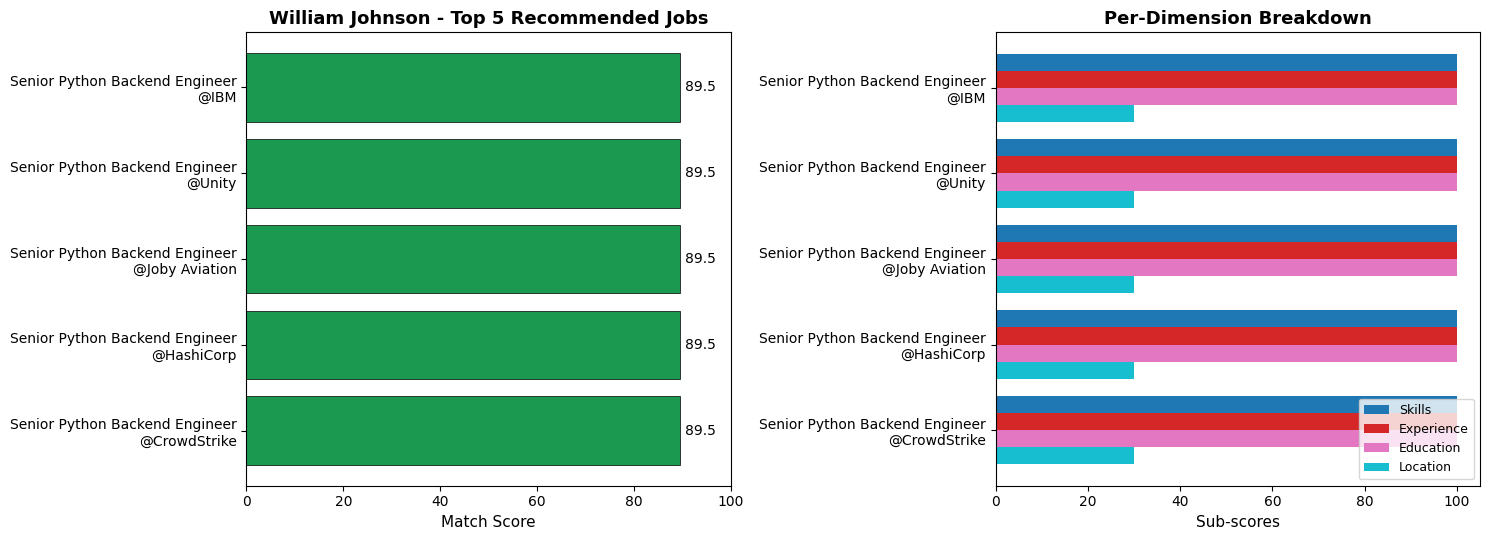

In [5]:
def plot_top_matches(results_df, candidate_name, top_n=5):
    """Visualize the top-N matched jobs."""
    top = results_df.head(top_n).copy()
    labels = [f"{r.title}\n@{r.company}" for r in top.itertuples()]

    fig, axes = plt.subplots(1, 2, figsize=(15, 0.7 * top_n + 2))

    # Total score
    colors = plt.cm.RdYlGn(top["total_score"] / 100)
    axes[0].barh(labels, top["total_score"], color=colors, edgecolor="black", linewidth=0.5)
    axes[0].set_xlabel("Match Score", fontsize=11)
    axes[0].set_title(f"{candidate_name} - Top {top_n} Recommended Jobs", fontsize=13, fontweight="bold")
    axes[0].set_xlim(0, 100)
    axes[0].invert_yaxis()
    for i, v in enumerate(top["total_score"]):
        axes[0].text(v + 1, i, f"{v}", va="center", fontsize=10)

    # Sub-scores
    breakdown = top[["skill_score", "exp_score", "edu_score", "loc_score"]].copy()
    breakdown.columns = ["Skills", "Experience", "Education", "Location"]
    breakdown.index = labels
    breakdown.plot.barh(ax=axes[1], colormap="tab10", width=0.8)
    axes[1].set_xlabel("Sub-scores", fontsize=11)
    axes[1].set_title("Per-Dimension Breakdown", fontsize=13, fontweight="bold")
    axes[1].set_xlim(0, 105)
    axes[1].invert_yaxis()
    axes[1].legend(loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()

# Demo run
plot_top_matches(demo_result, demo_cand["name"], top_n=5)


---

## Module 4: Parameter Interaction

`ipywidgets`-powered interactive panel:

- **Candidate selector**
- **Four weight sliders** (skills / experience / education / location — auto-normalized)
- **Location filter** (multi-select)
- **Minimum salary filter**
- **Top-N control**
- **LLM analysis toggle** (for top 1 job)

Click **Match** to recompute and visualize.


In [6]:
def build_ui():
    """Build the interactive UI."""
    candidate_dropdown = widgets.Dropdown(
        options=[(f"{c['name']} | {c['education']} | {c['experience_years']}y | {c['preferred_location']}", c["candidate_id"]) for _, c in candidates_df.iterrows()],
        description="Candidate:",
        layout=widgets.Layout(width="600px"),
        style={"description_width": "80px"},
    )

    w_skill = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.05, description="Skills:", style={"description_width": "100px"})
    w_exp = widgets.FloatSlider(value=0.2, min=0, max=1, step=0.05, description="Experience:", style={"description_width": "100px"})
    w_edu = widgets.FloatSlider(value=0.15, min=0, max=1, step=0.05, description="Education:", style={"description_width": "100px"})
    w_loc = widgets.FloatSlider(value=0.15, min=0, max=1, step=0.05, description="Location:", style={"description_width": "100px"})

    location_filter = widgets.SelectMultiple(
        options=["Any"] + sorted(jobs_df["location"].unique().tolist()),
        value=["Any"],
        description="Locations:",
        layout=widgets.Layout(width="320px", height="120px"),
        style={"description_width": "80px"},
    )

    salary_min = widgets.IntSlider(value=0, min=0, max=300000, step=10000, description="Min Salary:", style={"description_width": "80px"})
    top_n = widgets.IntSlider(value=5, min=3, max=15, description="Top N:", style={"description_width": "80px"})
    use_llm = widgets.Checkbox(value=True, description="Run Qwen analysis on Top 1")

    run_btn = widgets.Button(description="Match", button_style="primary", icon="search", layout=widgets.Layout(width="200px"))
    output = widgets.Output()

    def on_click(_):
        with output:
            clear_output(wait=True)
            cand_id = candidate_dropdown.value
            candidate = candidates_df[candidates_df["candidate_id"] == cand_id].iloc[0]

            # Normalize weights
            total_w = w_skill.value + w_exp.value + w_edu.value + w_loc.value
            if total_w == 0:
                print("All weights are zero — set at least one dimension.")
                return
            weights = {
                "skills": w_skill.value / total_w,
                "experience": w_exp.value / total_w,
                "education": w_edu.value / total_w,
                "location": w_loc.value / total_w,
            }

            # Apply filters
            filtered = jobs_df.copy()
            if "Any" not in location_filter.value:
                filtered = filtered[filtered["location"].isin(location_filter.value)]
            filtered = filtered[filtered["salary_max"] >= salary_min.value]
            if len(filtered) == 0:
                print("No jobs match the current filters — try relaxing them.")
                return

            results = match_all_jobs(candidate, filtered, weights)

            print(f"Candidate: {candidate['name']} | {candidate['education']} | {candidate['experience_years']} years")
            print(f"Normalized weights: Skills {weights['skills']:.0%} | Experience {weights['experience']:.0%} | Education {weights['education']:.0%} | Location {weights['location']:.0%}")
            print(f"Jobs after filter: {len(filtered)} / {len(jobs_df)}\n")

            show_n = min(top_n.value, len(results))
            styled = (
                results.head(show_n)
                .style.background_gradient(subset=["total_score"], cmap="Greens")
                .background_gradient(subset=["skill_score"], cmap="Blues")
                .format({"total_score": "{:.1f}", "skill_score": "{:.1f}", "exp_score": "{:.1f}", "edu_score": "{:.1f}", "loc_score": "{:.1f}"})
            )
            display(styled)

            plot_top_matches(results, candidate["name"], top_n=show_n)

            if use_llm.value and len(results) > 0:
                print("\n" + "=" * 60)
                print("Qwen Analysis (Top 1 Recommendation)")
                print("=" * 60)
                top_row = results.iloc[0]
                top_job = jobs_df[jobs_df["job_id"] == top_row["job_id"]].iloc[0]
                top_scores = {
                    "total": top_row["total_score"],
                    "skill": top_row["skill_score"],
                    "experience": top_row["exp_score"],
                    "education": top_row["edu_score"],
                    "location": top_row["loc_score"],
                }
                explanation = llm_explain_match(candidate, top_job, top_scores)
                display(Markdown(explanation))

    run_btn.on_click(on_click)

    return widgets.VBox([
        widgets.HTML("<h3 style='color:#2c5282'>Candidate &mdash; Job Intelligent Matching</h3>"),
        widgets.HTML("<p style='color:#666'>Adjust weights and filters, then click <b>Match</b>.</p>"),
        candidate_dropdown,
        widgets.HBox([w_skill, w_exp]),
        widgets.HBox([w_edu, w_loc]),
        widgets.HBox([location_filter, widgets.VBox([salary_min, top_n, use_llm])]),
        run_btn,
        output,
    ])

ui = build_ui()
display(ui)


---

## 5. Global Insight

Run every candidate × job pair to produce a Top-3 summary for each candidate — useful for HR to spot supply/demand mismatches at a glance.


In [7]:
def build_global_matrix(weights=None):
    """Compute match score for every candidate × job pair."""
    if weights is None:
        weights = {"skills": 0.5, "experience": 0.2, "education": 0.15, "location": 0.15}
    rows = []
    for _, c in candidates_df.iterrows():
        row = {"Candidate": c["name"]}
        for _, j in jobs_df.iterrows():
            row[f"{j['title'][:12]}({j['job_id']})"] = calculate_match(c, j, weights)["total"]
        rows.append(row)
    return pd.DataFrame(rows).set_index("Candidate")

matrix = build_global_matrix()
print(f"Global match matrix: {matrix.shape[0]} candidates x {matrix.shape[1]} jobs")
print("Top 3 recommended jobs per candidate:\n")

top3_summary = []
for cand_name in matrix.index:
    row = matrix.loc[cand_name].sort_values(ascending=False).head(3)
    top3_summary.append({
        "Candidate": cand_name,
        "Top1 Job": row.index[0], "Top1 Score": row.iloc[0],
        "Top2 Job": row.index[1], "Top2 Score": row.iloc[1],
        "Top3 Job": row.index[2], "Top3 Score": row.iloc[2],
    })
display(pd.DataFrame(top3_summary).style.background_gradient(subset=["Top1 Score", "Top2 Score", "Top3 Score"], cmap="Greens"))


Global match matrix: 153 candidates x 1070 jobs
Top 3 recommended jobs per candidate:



,Candidate,Top1 Job,Top1 Score,Top2 Job,Top2 Score,Top3 Job,Top3 Score
0,William Johnson,Senior Pytho(J0011),89.500000,Senior Pytho(J0012),89.500000,Senior Pytho(J0009),89.500000
1,Andrew Lopez,Python Backe(J0017),80.500000,Python Backe(J0020),79.500000,Python Backe(J0014),76.200000
2,Ahmed Brown,Java Backend(J0031),100.000000,Java Backend(J0024),89.500000,Java Backend(J0027),89.500000
3,Priya Mitchell,Senior Java (J0037),79.300000,Senior Java (J0033),79.300000,Java Backend(J0024),77.800000
4,Carlos Nelson,Go Backend E(J0046),82.200000,Go Backend E(J0052),82.200000,Go Backend E(J0051),80.500000
5,Wei Hernandez,Go Backend E(J0048),83.300000,Go Backend E(J0051),83.300000,Go Backend E(J0046),83.300000
6,Nadia Miller,Node.js Back(J0066),95.500000,Node.js Back(J0071),89.500000,Node.js Back(J0067),89.500000
7,Jason Campbell,Full Stack E(J0222),88.200000,Full Stack E(J0219),88.200000,Full Stack E(J0213),88.200000
8,Emma Clark,Ruby on Rail(J0081),100.000000,Ruby on Rail(J0077),95.500000,Ruby on Rail(J0076),95.000000
9,Christine Yamamoto,Rust Systems(J0089),100.000000,Rust Systems(J0087),100.000000,Rust Systems(J0084),96.000000


---

## 6. Summary & Future Work

### Implemented
1. **Data input** - CSV loading for job and candidate databases
2. **Analysis & decision** - 4-dimension weighted scoring with weight normalization
3. **Results display** - sorted table + dual bar charts + global heatmap
4. **Parameter interaction** - 9 ipywidgets controls
5. **Hybrid skill matching** - exact keyword overlap blended with **TF-IDF + cosine similarity** (scikit-learn) for semantic credit
6. **LLM enhancement** - Qwen generates natural-language match explanations

### Limitations
- TF-IDF captures shared-context similarity but not deep synonymy (a learned embedding model would link e.g. "PyTorch" and "TensorFlow" more reliably)
- Small sample size; not validated against real resumes
- LLM call latency and cost not optimized (caching / batching would help in production)